SETUP

In [1]:
import pandas as pd
import numpy as np


In [2]:
run_id_main = 49265
file_main = f"run/{run_id_main}/results_joined.tsv"

In [ ]:
# main dataframe
df = pd.read_csv(file_main, sep='\t', header=0)
df.head()

,hash,mode,wlhash,stabilized_at,cpu_time_s,max_mem_kib,local,isohash,family,result,...,cls5,cls6,cls7,cls8,cls9,cls10p,horn,invhorn,positive,negative
0,00063d88244921d6ec46aeab6866a8e2,none,ea8fa0f0ecfb333e,26.0,8.746190,29144,/nfs/share/instances/gbd/cnf/00063d88244921d6e...,d642ae7fc5e1fd972d4b130407ea4519,miter,unsat,...,0,0,0,0,0,0,68623,47944,13315,36581
1,00072cf107ae1349c8c59a15c5ce4af1,none,9e072dca530d7a40,4.0,0.046623,0,/nfs/share/instances/gbd/cnf/00072cf107ae1349c...,1ef05341ba4017bd107a9b2aa6bb2841,uniform-random,unknown,...,0,0,0,0,0,0,624,651,176,156
2,00076733bdbce94d7e44eca84f1425f0,none,5dac3f1f46833edc,9.0,50.312800,342256,/nfs/share/instances/gbd/cnf/00076733bdbce94d7...,a10da8b861b1e1a1a17af27060e94f6e,petrinet-concurrency,unsat,...,1,1,1,1,1,370,1561890,379,379,1561889
3,000781b7a545fe723159e53127aff659,none,45a7d68952db5ce9,24.0,65.481200,154584,/nfs/share/instances/gbd/cnf/000781b7a545fe723...,8bf4adb12d796e486a0915ecd7dce20f,station-repacking,unknown,...,4,2,0,9,4,1285,652179,1309,1309,652176
4,000a41cdca43be89ed62ea3abf2d0b64,none,8817ec1923525b06,12.0,34.683300,228120,/nfs/share/instances/gbd/cnf/000a41cdca43be89e...,bb3b6ceaeee2d5e9fd8e1066389a8a94,sorting-networks,sat,...,0,0,6,0,0,91,680173,110547,4244,58680


DATA GATHERING

In [4]:
df2 = df.copy()

# cleaning
for c in ['wlhash', 'stabilized_at']:
    if c in df2.columns:
        df2[c] = df2[c].replace({'NA': pd.NA, '': pd.NA})

# mode
if 'mode' in df2.columns:
    df2['mode'] = pd.Categorical(df2['mode'], categories=['none','adv','sum'], ordered=True)

# max_iters
if 'max_iters' in df2.columns:
    df2['max_iters'] = pd.to_numeric(df2['max_iters'], errors='coerce').astype('Int64')

# groupings
if 'mode' in df2.columns:
    g = df2.groupby('mode', observed=True)
    per_mode = pd.DataFrame({
        'TOTAL': g.size(),
        'NA': g['wlhash'].apply(lambda x: x.isna().sum()),
        'UNIQUE': g['wlhash'].nunique(dropna=True)
    })
    if 'max_iters' in df2.columns:
        g2 = df2.groupby(['mode','max_iters'], observed=True, dropna=False)
        per_mode_iters = pd.DataFrame({
            'TOTAL': g2.size(),
            'NA': g2['wlhash'].apply(lambda x: x.isna().sum()),
            'UNIQUE': g2['wlhash'].nunique(dropna=True)
        })

# Overall metrics
total = len(df2)
na = df2['wlhash'].isna().sum()
unique = df2['wlhash'].nunique(dropna=True)
same = total - unique - na

# stabilization
if 'stabilized_at' in df2.columns:
    df2['stabilized_at_num'] = pd.to_numeric(df2['stabilized_at'], errors='coerce')

# avg stabilization
overall_avg_stab = df2['stabilized_at_num'].mean(skipna=True)
if 'mode' in df2.columns:
    per_mode['AVG_STAB'] = g['stabilized_at_num'].mean()
    if 'max_iters' in df2.columns:
        per_mode_iters['AVG_STAB'] = g2['stabilized_at_num'].mean()

PRINTING

In [5]:
print(f"UNIQUE: {unique}")
print(f"NA:     {na}")
print(f"SAME:   {same}")
print(f"\nAVG stabilization point (overall): {overall_avg_stab:.3f}")

# Per-mode breakdown
if 'mode' in df2.columns:
    print("\nBY mode:")
    print(per_mode.to_string())
    if 'max_iters' in df2.columns:
        print("\nBY mode, max_iters:")
        print(per_mode_iters.to_string())

UNIQUE: 59376
NA:     458
SAME:   34543

AVG stabilization point (overall): 20.054

BY mode:
      TOTAL   NA  UNIQUE   AVG_STAB
mode                               
none  31459  165   29669  20.048537
adv   31459  166   29668  20.048331
sum   31459  127   29706  20.064611


PLOTS

In [6]:
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

**Analyzing Positives**

FAMILIES

In [11]:
# CELL 1 — Prep once: filter, clean, scope to mode=none and wlhash appearing > 1 time

df1 = df.copy()

# filter and clean
df1 = df1[df1['mode'] == 'none'].copy()
df1['wlhash'] = df1['wlhash'].replace({'NA': pd.NA, '': pd.NA})
df1['family'] = df1['family'].replace({'': pd.NA})

# rows with valid wlhash
_valid = df1[['wlhash', 'family']].dropna(subset=['wlhash'])

# restrict to wlhash that appear more than once
_dups = _valid['wlhash'].value_counts()
dup_rows = _valid[_valid['wlhash'].isin(_dups[_dups > 1].index)].copy()

# helpers reused by later cells
def _famcounts_str(s):
    vals = s.dropna().astype(str).str.strip()
    pairs = sorted(vals.value_counts().items(), key=lambda kv: (-kv[1], kv[0]))
    return ', '.join(f'{k}:{v}' for k, v in pairs)

def _famset_sorted(s):
    return sorted({x for x in s.dropna().astype(str).str.strip() if x})

def _combo_label(fam_list):
    return ' + '.join(fam_list)


In [ ]:
# CELL 2 — Per-wlhash details: totals and per-family counts (only wlhash with >1 family)

g = dup_rows.groupby('wlhash', observed=True)
per_wlhash = (
    pd.DataFrame({
        'total_instances': g.size(),
        'num_families': g['family'].nunique(dropna=True),
        'families': g['family'].apply(lambda s: ', '.join(_famset_sorted(s))),
        'family_counts': g['family'].apply(_famcounts_str),
    })
    .reset_index()
)

per_wlhash = per_wlhash[per_wlhash['num_families'] > 1].sort_values(
    ['num_families', 'total_instances', 'wlhash'], ascending=[False, False, True]
)

print(f"{len(per_wlhash)} wlhash values with multiple families in mode=none")
display(per_wlhash)

18 wlhash values with multiple families in mode=none


,wlhash,total_instances,num_families,families,family_counts
262,45f3bc1ced651cad,20,2,"graph-based, tseitin-formulas","tseitin-formulas:18, graph-based:2"
588,a5ce118e1f864f07,6,2,"miter, xor-chain","miter:5, xor-chain:1"
38,08f753fdfe927a42,5,2,"graph-based, tseitin-formulas","tseitin-formulas:3, graph-based:2"
449,7e23de98201a1c06,5,2,"graph-based, tseitin-formulas","graph-based:3, tseitin-formulas:2"
635,b0ea13cac65b6016,5,2,"graph-based, tseitin-formulas","tseitin-formulas:3, graph-based:2"
661,b7a5ac965a880dbc,5,2,"graph-based, tseitin-formulas","tseitin-formulas:3, graph-based:2"
68,11fbe957eed4e935,4,2,"cryptography, software-verification","cryptography:2, software-verification:2"
410,746ba6407ff55b46,4,2,"graph-based, tseitin-formulas","tseitin-formulas:3, graph-based:1"
618,ada1aa02b5ab1be9,4,2,"philips, unknown","philips:3, unknown:1"
692,bf1a9f23f6bf2347,4,2,"graph-based, tseitin-formulas","tseitin-formulas:3, graph-based:1"


In [ ]:
# CELL 3 — Group by family combination across wlhash

g2 = dup_rows.groupby('wlhash', observed=True)
per_hash_combo = (
    g2['family'].agg(
        families=lambda s: _famset_sorted(s),
        total_instances='size'
    ).reset_index()
)
per_hash_combo['num_families'] = per_hash_combo['families'].apply(len)
per_hash_combo = per_hash_combo[per_hash_combo['num_families'] > 1].copy()
per_hash_combo['family_combo'] = per_hash_combo['families'].apply(_combo_label)

combo_summary = (
    per_hash_combo.groupby(['family_combo', 'num_families'], observed=True)
    .agg(
        wlhash_count=('wlhash', 'nunique'),
        instances_count=('total_instances', 'sum'),
    )
    .reset_index()
    .sort_values(['wlhash_count', 'instances_count', 'num_families', 'family_combo'],
                 ascending=[False, False, False, True])
)

print(f"{len(combo_summary)} family combinations with multiple families (mode=none)")
display(combo_summary)


7 family combinations with multiple families (mode=none)


,family_combo,num_families,wlhash_count,instances_count
4,graph-based + tseitin-formulas,2,10,56
2,cryptography + software-verification,2,3,10
5,miter + xor-chain,2,1,6
6,philips + unknown,2,1,4
1,coloring + mycielski-graph,2,1,3
0,clique-colouring + coloring,2,1,2
3,dining-philosophers + misc-satex,2,1,2


In [15]:
# CELL 4 — Per-family summary: unique wlhash count and total instances (singular family view)

per_family = (
    dup_rows.dropna(subset=['family'])
    .groupby('family', observed=True)['wlhash']
    .agg(wlhash_count='nunique', instances_count='size')
    .reset_index()
    .sort_values(['wlhash_count', 'instances_count', 'family'], ascending=[False, False, True])
)

print(f"{len(per_family)} families in mode=none (within wlhash that appear >1 time)")
display(per_family)


79 families in mode=none (within wlhash that appear >1 time)


,family,wlhash_count,instances_count
29,hardware-verification,109,276
46,planning,99,220
12,coloring,56,351
37,miter,52,163
14,cryptography,51,116
...,...,...,...
60,random-mus,1,2
63,relativized-pigeon-hole,1,2
70,stedman-triples,1,2
71,stone,1,2


**Hash Behaviour Plots** (Unique)

In [7]:
sns.lineplot(data=avg, x='max_iters', y='unique', hue='mode', marker='o')
plt.title('Unique Hashes by iteration limit')
plt.xlabel('max_iters'); plt.ylabel('unique hashes')
plt.show()


NameError: name 'avg' is not defined

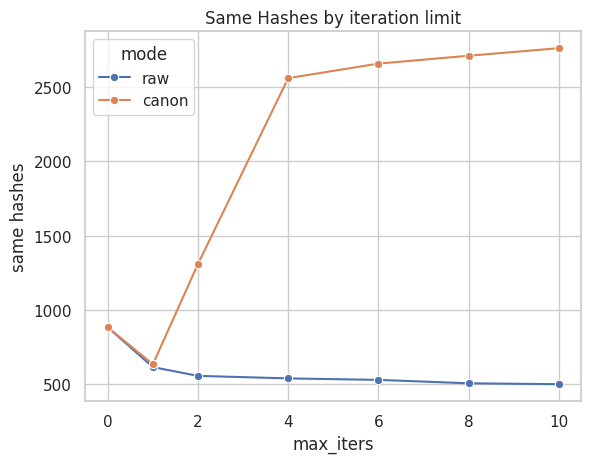

In [41]:
sns.lineplot(data=avg, x='max_iters', y='same', hue='mode', marker='o')
plt.title('Same Hashes by iteration limit')
plt.xlabel('max_iters'); plt.ylabel('same hashes')
plt.show()

In [ ]:
sns.lineplot(data=avg, x='max_iters', y='na', hue='mode', marker='o')
plt.title('NA Hashes by iteration limit')
plt.xlabel('max_iters'); plt.ylabel('NA hashes')
plt.show()

In [8]:
# --- minimal prep (safe to rerun) ---
hash_col = 'hash' if 'hash' in df.columns else 'isohash'
df2 = df.copy()
df2[hash_col]      = df2[hash_col].replace({'NA': pd.NA})
df2['cpu_time_s']  = pd.to_numeric(df2.get('cpu_time_s'),  errors='coerce')
df2['max_mem_kib'] = pd.to_numeric(df2.get('max_mem_kib'), errors='coerce')
if 'mode' in df2.columns:
    df2['mode'] = pd.Categorical(df2['mode'], categories=['raw','canon'], ordered=True)

# --- label each row as unique vs same within (max_iters, mode) ---
counts = (
    df2.groupby(['max_iters','mode'])[hash_col]
       .transform(lambda s: s.map(s.value_counts(dropna=True)))
)
df2['hash_status'] = np.where(
    df2[hash_col].isna(), 'na',
    np.where(counts == 1, 'unique', 'same')
)

# drop NA-hash rows for this comparison
df3 = df2[df2['hash_status'] != 'na'].copy()

# --- averages by iteration, mode, and uniqueness ---
summary = (df3
    .groupby(['max_iters','mode','hash_status'], as_index=False)
    .agg(avg_cpu_s=('cpu_time_s','mean'),
         avg_mem_kib=('max_mem_kib','mean'),
         n=('hash_status','size'))
    .sort_values(['max_iters','mode','hash_status'])
)
# nice numeric dtype for x-axis
summary['max_iters'] = pd.to_numeric(summary['max_iters'], errors='coerce').astype('Int64')

# ---- lineplots ----
# CPU time
sns.lineplot(
    data=summary,
    x='max_iters', y='avg_cpu_s',
    hue='hash_status', style='mode', marker='o'
)
plt.title('Avg CPU time by iteration, split by unique vs same')
plt.xlabel('max_iters'); plt.ylabel('seconds')
plt.show()

# Memory
sns.lineplot(
    data=summary,
    x='max_iters', y='avg_mem_kib',
    hue='hash_status', style='mode', marker='o'
)
plt.title('Avg memory by iteration, split by unique vs same')
plt.xlabel('max_iters'); plt.ylabel('KiB')
plt.show()

KeyError: 'max_iters'

**Performance Plots** (CPU, Memory)

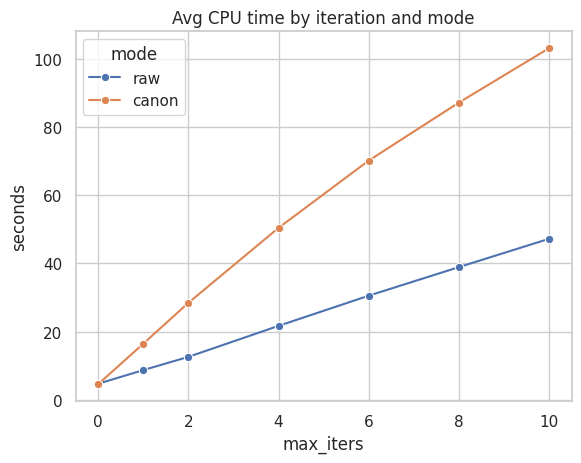

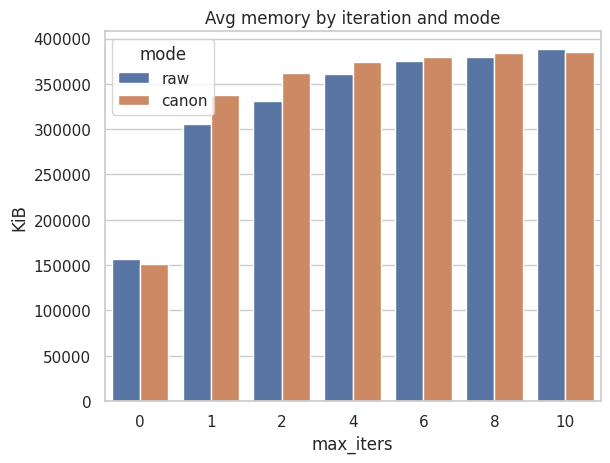

In [38]:
sns.lineplot(data=avg, x='max_iters', y='avg_cpu_s', hue='mode', marker='o')
plt.title('Avg CPU time by iteration and mode')
plt.xlabel('max_iters'); plt.ylabel('seconds')
plt.show()

sns.barplot(data=avg, x='max_iters', y='avg_mem_kib', hue='mode')
plt.title('Avg memory by iteration and mode'); plt.xlabel('max_iters'); plt.ylabel('KiB')
plt.show()


GET ALL DUPLICATE HASHES AND THEIR INSTANCES

In [9]:
# adding isohash to duplicated hashes of main to compare
dupe_rows = df[df['hash'].duplicated(keep=False)].sort_values('hash')
merged = dupe_rows.merge(
    df_comp[['ID','isohash']],
    on='ID',
    how='left'
)
print(merged.head(10))

NameError: name 'df_comp' is not defined

In [8]:
# adding hash of main to duplicated hashes of isohash
dupe_rows_comp = df_comp[df_comp['isohash'].duplicated(keep=False)].sort_values('isohash')
merged = dupe_rows_comp.merge(
    df[['ID','hash']],
    on='ID',
    how='left'
)
print(merged.head(10))

                                 ID                           isohash  \
0  4666906deb05406c0ecc18de81673d76  00a1a353e84e203de503f206c02b7a2c   
1  4666906deb05406c0ecc18de81673d76  00a1a353e84e203de503f206c02b7a2c   
2  ae07d3502702cd744ad48e254abb192f  00a1a353e84e203de503f206c02b7a2c   
3  ae07d3502702cd744ad48e254abb192f  00a1a353e84e203de503f206c02b7a2c   
4  74acaa627ddc5fdab40d62172f56a827  00c5b384d9311d83da0be53e990b4904   
5  74acaa627ddc5fdab40d62172f56a827  00c5b384d9311d83da0be53e990b4904   
6  66ab346df72c5effa292342037bc3909  00c5b384d9311d83da0be53e990b4904   
7  66ab346df72c5effa292342037bc3909  00c5b384d9311d83da0be53e990b4904   
8  df3da7a967605e804571a36c099416b7  00efc6678bd4710b52c3448cc6e9c5da   
9  df3da7a967605e804571a36c099416b7  00efc6678bd4710b52c3448cc6e9c5da   

               hash  
0  cc59bf95d464f26e  
1  a92e9acdee3d7306  
2  cc59bf95d464f26e  
3  a92e9acdee3d7306  
4  28a3415cc12d2e15  
5  d113037ad7d90966  
6  28a3415cc12d2e15  
7  d113037ad7d90966 